In [10]:
import pandas as pd
import hashlib as hl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [11]:
df_program = pd.read_csv("athlete_events.csv")
df_program["Name"] = df_program["Name"].apply(lambda x: hl.sha256(str(x).encode("utf-8")).hexdigest())
df_program = df_program[df_program["Team"] == "France"].sort_values("Year")
df_program.dropna(subset=["Year", "Medal"], inplace=True)

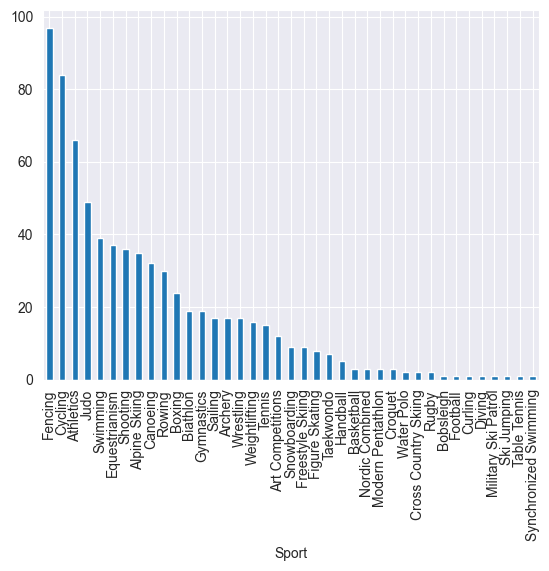

In [18]:
sporter = df_program.drop_duplicates(subset=["Year", "Event"]).sort_values("Sport").value_counts("Sport").plot(kind="bar")

In [13]:
#antal medaljer per OS
medals_per_games = fra_medals.groupby("Games")["Medal"].count()

px.line(medals_per_games, title="Antal medaljer per OS (Frankrike)")

In [14]:
sports = ["Fencing", "Athletics", "Cycling", "Swimming"]
df_sports = df_program[df_program["Sport"].isin(sports)]

In [15]:
df_medals = df_sports[df_sports["Medal"].notna()]

medals_by_country = df_medals.groupby(["Sport", "Team"])["Medal"].count().reset_index()


px.bar(medals_by_country,x="Team", y="Medal", color="Sport",title="Medaljfördelning i utvalda sporter", width=800, height=500)

In [16]:
df_age = df_sports[df_sports["Age"].notna()]

px.histogram(df_age, x="Age", color="Sport", barmode="overlay",
             title="Åldersfördelning i sporterna")

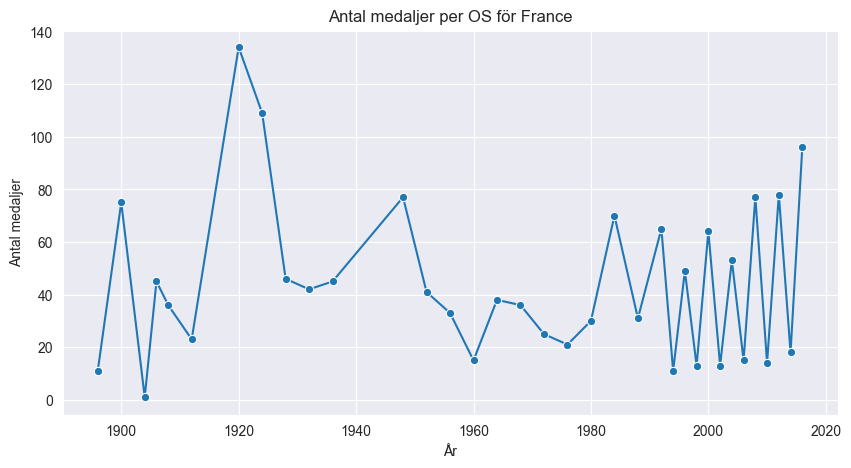

In [19]:
#antal medaljer per OS år
country = "France"
medals_per_year = df_program.groupby("Year")["Medal"].count()

plt.figure(figsize=(10,5))
sns.lineplot(x=medals_per_year.index, y=medals_per_year.values, marker="o")
plt.title(f"Antal medaljer per OS för {country}")
plt.xlabel("År")
plt.ylabel("Antal medaljer")
plt.grid(True)
plt.show()

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(data=medals, x="Age", bins=15, kde=True)
plt.title(f"Åldersfördelning bland medaljtagare i {country}")
plt.xlabel("Ålder")
plt.ylabel("Antal idrottare")
plt.show()

NameError: name 'medals' is not defined

<Figure size 800x500 with 0 Axes>